# House Price Prediction - Phase 1: Foundation & Prototype
### Ames Housing Dataset (Kaggle House Prices)

| Step | Topic |
|------|-------|
| 1 | Data Loading & Overview |
| 2 | Data Preprocessing |
| 3 | Exploratory Data Analysis |
| 4 | Linear Regression (Baseline) |
| 5 | Evaluation: MAE, RMSE, R2 |


## Step 1: Data Loading & Overview

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import warnings; warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

raw = pd.read_csv('data/train.csv')
print(f"Rows: {raw.shape[0]}  |  Cols: {raw.shape[1]}")
print(f"Numeric: {raw.select_dtypes('number').shape[1]}  |  Categorical: {raw.select_dtypes('object').shape[1]}")
print("\nSalePrice Stats:")
print(raw['SalePrice'].describe().apply(lambda x: f'${x:,.0f}'))
raw.head()


Rows: 2930  |  Cols: 81
Numeric: 38  |  Categorical: 43

SalePrice Stats:
count      $2,930
mean     $180,796
std       $79,887
min       $12,789
25%      $129,500
50%      $160,000
75%      $213,500
max      $755,000
Name: SalePrice, dtype: object


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


## Step 2: Data Preprocessing
### 2a. Missing Values

Columns with missing data: 27
PoolQC          99.556314
MiscFeature     96.382253
Alley           93.242321
Fence           80.477816
MasVnrType      60.580205
FireplaceQu     48.532423
LotFrontage     16.723549
GarageYrBlt      5.426621
GarageCond       5.426621
GarageQual       5.426621
GarageFinish     5.426621
GarageType       5.358362
BsmtExposure     2.832765
BsmtFinType2     2.764505
BsmtCond         2.730375
BsmtQual         2.730375
BsmtFinType1     2.730375
MasVnrArea       0.784983
BsmtFullBath     0.068259
BsmtHalfBath     0.068259


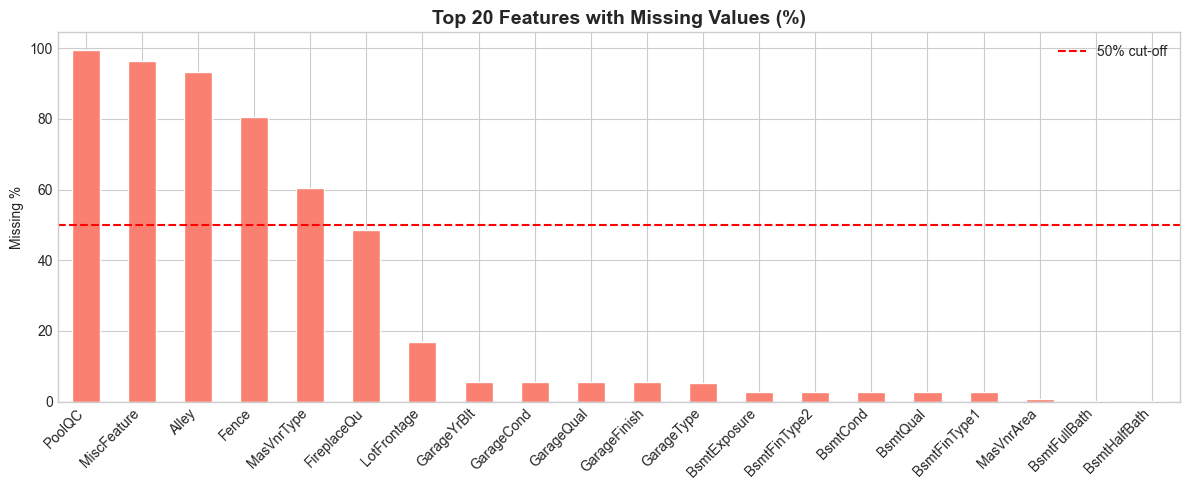

In [2]:
miss_pct = (raw.isnull().sum() / len(raw) * 100).sort_values(ascending=False)
miss_pct = miss_pct[miss_pct > 0]
print(f"Columns with missing data: {len(miss_pct)}")
print(miss_pct.head(20).to_string())

fig, ax = plt.subplots(figsize=(12, 5))
miss_pct.head(20).plot(kind='bar', ax=ax, color='salmon', edgecolor='white')
ax.axhline(50, color='red', ls='--', lw=1.5, label='50% cut-off')
ax.set_title('Top 20 Features with Missing Values (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('Missing %'); ax.legend()
plt.xticks(rotation=45, ha='right'); plt.tight_layout()
plt.savefig('missing_values.png', dpi=150); plt.show()


### 2b. Impute Missing Values

In [3]:
import pandas as pd, numpy as np, os, warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('data/train.csv')
df.drop(columns=['Id'], inplace=True, errors='ignore')
TARGET = 'SalePrice'

NONE_COLS = ['PoolQC','MiscFeature','Alley','Fence','FireplaceQu',
             'GarageType','GarageFinish','GarageQual','GarageCond',
             'BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2','MasVnrType']
for c in NONE_COLS:
    if c in df: df[c] = df[c].fillna('None')

df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))
for c in ['GarageYrBlt','GarageArea','GarageCars','BsmtFinSF1','BsmtFinSF2',
          'BsmtUnfSF','TotalBsmtSF','BsmtFullBath','BsmtHalfBath','MasVnrArea']:
    if c in df: df[c] = df[c].fillna(0)
for c in df.select_dtypes('object'):
    df[c] = df[c].fillna(df[c].mode()[0])

print(f"Shape: {df.shape}  |  Nulls remaining: {df.isnull().sum().sum()}")


Shape: (2930, 80)  |  Nulls remaining: 3


### 2c. One-Hot Encode Categoricals

In [4]:
cat_cols = df.select_dtypes('object').columns.tolist()
print(f"Encoding {len(cat_cols)} categorical columns...")
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print(f"Shape after encoding: {df.shape}")


Encoding 43 categorical columns...
Shape after encoding: (2930, 276)


### 2d. Train/Test Split & StandardScaler

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=[TARGET]); y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"SalePrice: ${y.min():,.0f} - ${y.max():,.0f}  |  Mean: ${y.mean():,.0f}")


Train: (2344, 275)  |  Test: (586, 275)
SalePrice: $12,789 - $755,000  |  Mean: $180,796


## Step 3: Exploratory Data Analysis (EDA)
### 3a. SalePrice Distribution

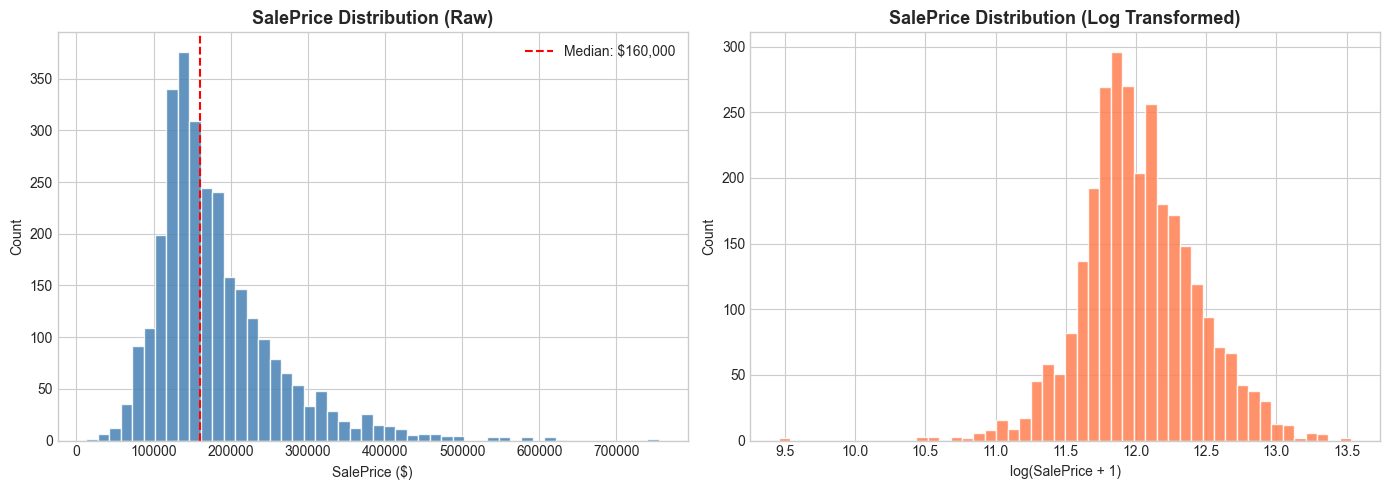

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(y, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(y.median(), color='red', ls='--', lw=1.5, label=f'Median: ${y.median():,.0f}')
axes[0].set_title('SalePrice Distribution (Raw)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('SalePrice ($)'); axes[0].set_ylabel('Count'); axes[0].legend()

axes[1].hist(np.log1p(y), bins=50, color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('SalePrice Distribution (Log Transformed)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log(SalePrice + 1)'); axes[1].set_ylabel('Count')

plt.tight_layout(); plt.savefig('target_distribution.png', dpi=150); plt.show()


### 3b. Correlation Heatmap — Top 15 Numeric Features

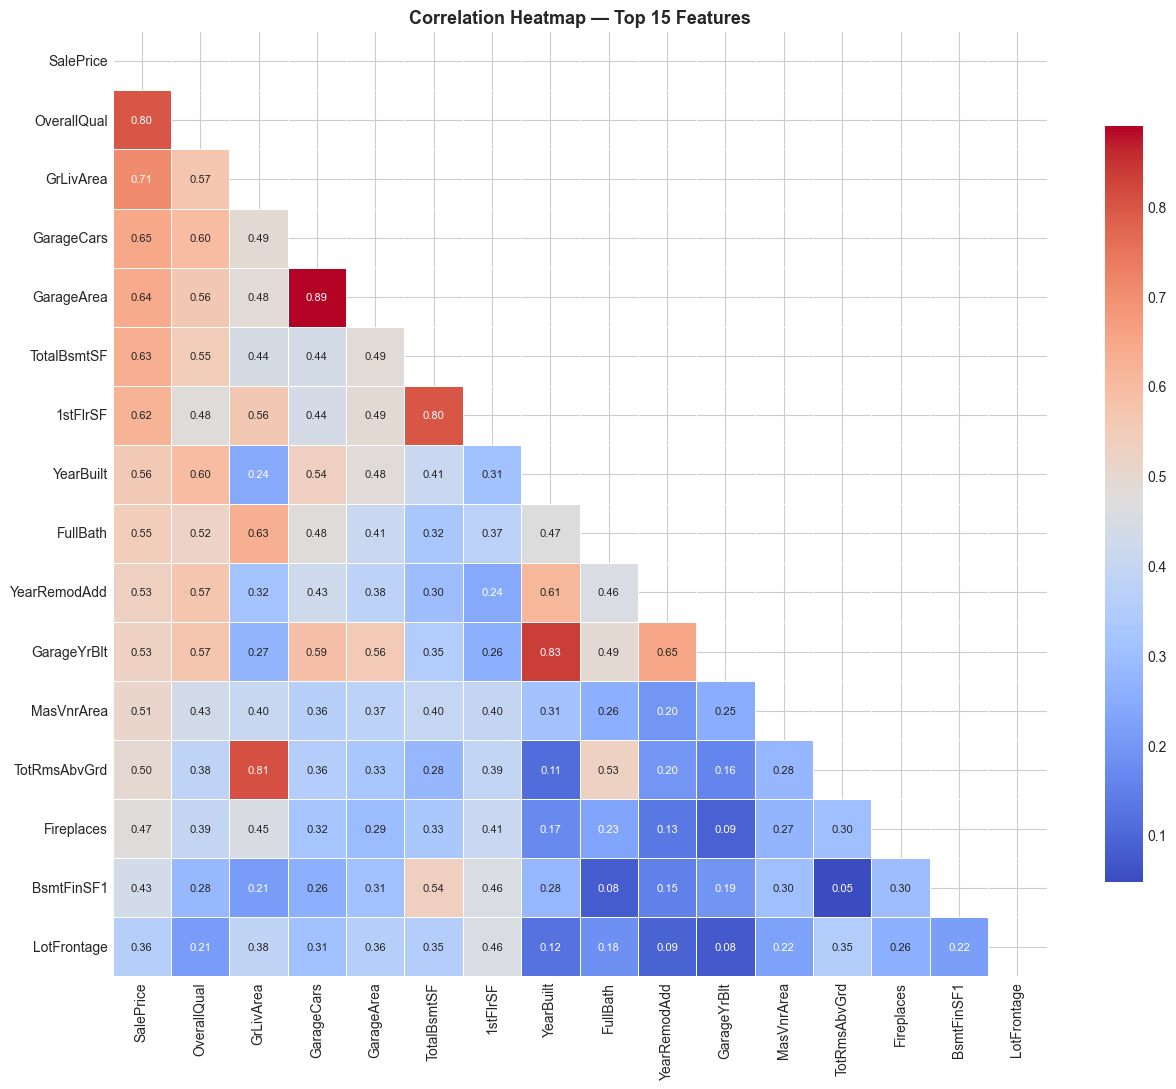

In [7]:
num_df = pd.read_csv('data/train.csv').select_dtypes('number').drop(columns=['Id'], errors='ignore')
corr   = num_df.corr()
top15  = corr['SalePrice'].abs().sort_values(ascending=False).head(16).index

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr.loc[top15, top15], dtype=bool))
sns.heatmap(corr.loc[top15, top15], annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8}, annot_kws={'size': 8})
ax.set_title('Correlation Heatmap — Top 15 Features', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('correlation_heatmap.png', dpi=150); plt.show()


### 3c. Key Feature Scatter Plots vs SalePrice

In [ ]:
raw = pd.read_csv('data/train.csv')
KEY = [('GrLivArea','Living Area (sqft)'), ('OverallQual','Overall Quality'),
       ('TotalBsmtSF','Basement Area (sqft)'), ('GarageCars','Garage Cars'),
       ('YearBuilt','Year Built'), ('1stFlrSF','1st Floor (sqft)')]
palette = sns.color_palette('husl', 6)

fig, axes = plt.subplots(2, 3, figsize=(16, 10)); axes = axes.flatten()
for i, (col, label) in enumerate(KEY):
    axes[i].scatter(raw[col], raw['SalePrice'], alpha=0.35, color=palette[i], s=14)
    z = np.polyfit(raw[col], raw['SalePrice'], 1)
    xl = np.linspace(raw[col].min(), raw[col].max(), 200)
    axes[i].plot(xl, np.poly1d(z)(xl), 'r--', lw=1.8)
    r = raw[[col,'SalePrice']].corr().iloc[0,1]
    axes[i].set_title(f'{label}  (r={r:.3f})', fontsize=10, fontweight='bold')
    axes[i].set_xlabel(label, fontsize=9); axes[i].set_ylabel('SalePrice ($)', fontsize=9)

plt.suptitle('Key Features vs SalePrice', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.savefig('scatter_plots.png', dpi=150); plt.show()


### 3d. Top 15 Feature Correlations with SalePrice

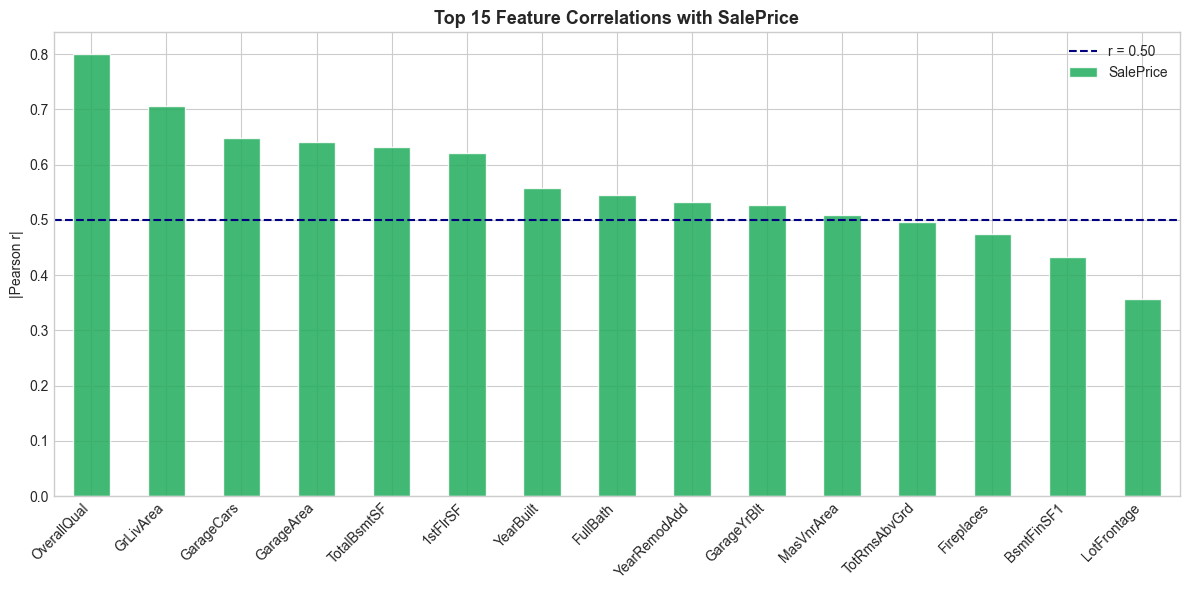

In [9]:
top_corr = corr['SalePrice'].drop('SalePrice').abs().sort_values(ascending=False).head(15)
colors = ['#27ae60' if corr['SalePrice'][f] > 0 else '#e74c3c' for f in top_corr.index]

fig, ax = plt.subplots(figsize=(12, 6))
top_corr.plot(kind='bar', ax=ax, color=colors, edgecolor='white', alpha=0.88)
ax.axhline(0.5, color='navy', ls='--', lw=1.5, label='r = 0.50')
ax.set_title('Top 15 Feature Correlations with SalePrice', fontsize=13, fontweight='bold')
ax.set_ylabel('|Pearson r|'); ax.legend()
plt.xticks(rotation=45, ha='right'); plt.tight_layout()
plt.savefig('feature_correlation_bar.png', dpi=150); plt.show()


### 3e. SalePrice by Quality & Neighbourhood

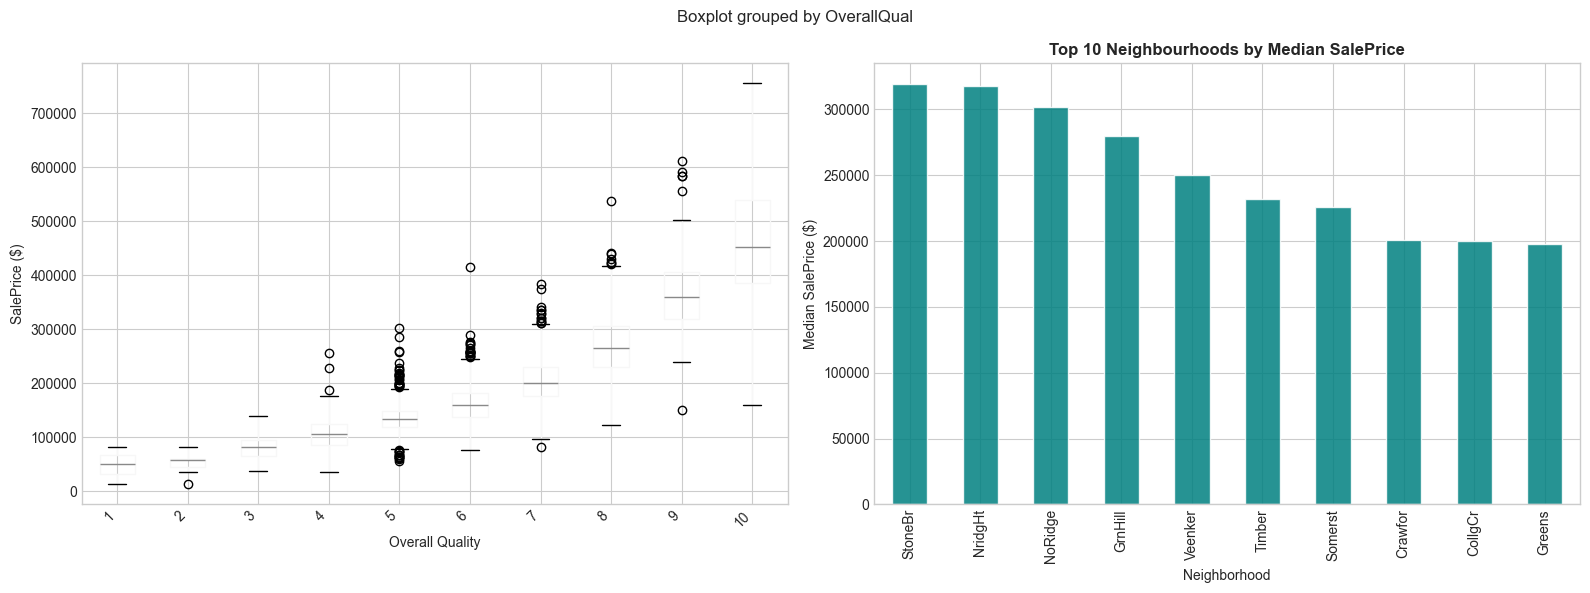

In [10]:
raw = pd.read_csv('data/train.csv')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

raw.boxplot(column='SalePrice', by='OverallQual', ax=axes[0])
axes[0].set_title('SalePrice by Overall Quality (1-10)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Overall Quality'); axes[0].set_ylabel('SalePrice ($)')
plt.sca(axes[0]); plt.title('')

top10 = raw.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).head(10)
top10.plot(kind='bar', ax=axes[1], color='teal', edgecolor='white', alpha=0.85)
axes[1].set_title('Top 10 Neighbourhoods by Median SalePrice', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Median SalePrice ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.savefig('neighbourhood_quality.png', dpi=150); plt.show()


## Step 4: Baseline Model — Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)
print("Linear Regression trained!")


## Step 5: Evaluation Metrics

In [ ]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"\n{'='*52}")
    print(f"  Model : {name}")
    print(f"{'─'*52}")
    print(f"  MAE   : ${mae:>12,.2f}  (avg dollar error)")
    print(f"  RMSE  : ${rmse:>12,.2f}  (penalises large errors)")
    print(f"  R2    : {r2:>13.4f}  (1.0 = perfect fit)")
    print(f"{'='*52}")
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

results = [evaluate('Linear Regression (Baseline)', y_test, y_pred_lr)]


In [ ]:
residuals = y_test - y_pred_lr
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

lim = [min(y_test.min(), y_pred_lr.min())*0.95, max(y_test.max(), y_pred_lr.max())*1.02]
axes[0].scatter(y_test, y_pred_lr, alpha=0.4, color='steelblue', s=14)
axes[0].plot(lim, lim, 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_xlabel('Actual SalePrice ($)'); axes[0].set_ylabel('Predicted ($)')
axes[0].set_title('Linear Regression: Predicted vs Actual', fontsize=12, fontweight='bold')
axes[0].legend()

axes[1].scatter(y_pred_lr, residuals, alpha=0.4, color='coral', s=14)
axes[1].axhline(0, color='black', lw=1.5, ls='--')
axes[1].set_xlabel('Predicted ($)'); axes[1].set_ylabel('Residual ($)')
axes[1].set_title('Residual Plot', fontsize=12, fontweight='bold')

plt.tight_layout(); plt.savefig('phase1_predictions.png', dpi=150); plt.show()


## Phase 1 Summary — Save Model

In [ ]:
import pickle, json
os.makedirs('models', exist_ok=True)
with open('models/scaler.pkl','wb')            as f: pickle.dump(scaler, f)
with open('models/linear_regression.pkl','wb')  as f: pickle.dump(lr, f)
with open('models/feature_names.json','w')      as f: json.dump(list(X_train.columns), f)
print(pd.DataFrame(results).to_string(index=False))
print("\nModels saved to models/")
print("Next -> phase2_notebook.ipynb")
